<a href="https://colab.research.google.com/github/d2021101420/PCO213/blob/main/PCO213_Treinam06_MAA%2BHL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

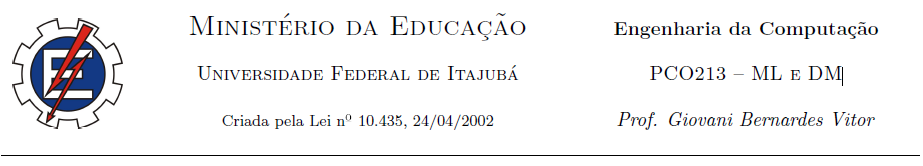

# Treinamento #6

**Observações:**

- Os códigos bem como as respostas textuais deverão ser enviados de maneira conjunta no arquivo com extensão .ipynb.
- Os demais arquivos, por exemplo, datasets podem ser enviados em formato compactado (.rar, .zip, etc.)
- Não serão aceitos o envio de arquivo no formato PDF ou DOC como resposta para o desenvolvimento das atividades.
- As atividades podem ser realizadas em grupos de no máximo 4 integrantes onde somente 1 deles será responsável pelo envio e postagem no SIGAA.
- Não serão aceitos a entrega das atividades fora do prazo e somente via SIGAA. Entregas via email não serão contabilizadas.
- Alguns exercícios exigem pesquisa extra-classe para cobrir todo o entendimento e conteúdo abordado neste treinamento.

### Matrícula e nome completo: *11.45.07 (UFOP) - HEBERT FERRAZ SOUZA LIMA*
### Matrícula e nome completo: *2026102180 - MAURÍCIO ANDRÉ DE ALMEIDA*


# Exercício 1 – Conceitos Fundamentais

**(a)** Árvore de decisão é um modelo que divide os dados em etapas sucessivas usando perguntas sobre atributos até chegar a uma decisão final.

**(b)** Aprendizagem incremental atualiza o modelo conforme novos dados chegam. A não incremental precisa ser treinada novamente usando todo o conjunto de dados.

**(c)** São modelos de caixa branca porque suas decisões podem ser facilmente interpretadas através dos nós e regras da árvore.

---

# Exercício 2 – Entropia Básica

Fórmula:

H(S) = -Σ p(i) log₂ p(i)

### (a) S1 = [10+,10−]

p+=0,5 ; p−=0,5

H=1,0

### (b) S2 = [8+,2−]

p+=0,8 ; p−=0,2

H = -(0,8 log₂0,8 + 0,2 log₂0,2)

H ≈ 0,722

### (c) S3 = [15+,0−]

H=0

Maior incerteza: S1, pois possui distribuição perfeitamente balanceada.

---

# Exercício 3 – Propriedades da Entropia

A entropia é máxima quando p+=0,5 e p−=0,5.

H = -(0,5 log₂0,5 + 0,5 log₂0,5)=1

Para p+=1 e p−=0:

H=0

Logo a alternativa correta é (a).



In [ ]:
import numpy as np
import pandas as pd
from collections import Counter

def entropy(labels):
    """Calcula a entropia de um conjunto de rótulos"""
    if len(labels) == 0:
        return 0
    counts = Counter(labels)
    probs = np.array([count / len(labels) for count in counts.values()])
    return -np.sum(probs * np.log2(probs + 1e-10))

# Exemplos
print('=== EXEMPLOS DE ENTROPIA ===')
print(f'Todos da mesma classe [A,A,A,A]: H = {entropy(["A","A","A","A"]):.4f}')
print(f'Distribuição uniforme [A,B,A,B]: H = {entropy(["A","B","A","B"]):.4f}')
print(f'Distribuição mista [A,A,B,C]: H = {entropy(["A","A","B","C"]):.4f}')


# Exercício 4 – Ganho de Informação

(a) Mede a redução da incerteza após particionar os dados.

(b) Quanto maior o ganho, melhor a separação das classes.

(c) Relaciona-se ao princípio da navalha de Occam porque busca divisões simples e informativas.

---

# Exercício 5 – Overfitting

(a) Ocorre quando a árvore aprende ruídos dos dados.

(b) Árvores profundas criam regras excessivamente específicas.

(c) Estratégias:
- Limitar profundidade (pre-pruning)
- Cost-complexity pruning (post-pruning)

---

# Exercício 6 – Play Tennis

Classe Jogar:
Yes = 6
No = 4

Entropia do conjunto:

H(S) ≈ 0,971

Ganho(Outlook) ≈ 0,322

Ganho(Temperatura) ≈ 0,096

A raiz deve ser Outlook por possuir maior ganho de informação.

---


In [ ]:
def information_gain(parent, left, right):
    """Calcula o ganho de informação de uma partição"""
    n = len(parent)
    n_left = len(left)
    n_right = len(right)

    if n_left == 0 or n_right == 0:
        return 0

    parent_entropy = entropy(parent)
    left_entropy = entropy(left)
    right_entropy = entropy(right)

    weighted_child_entropy = (n_left / n) * left_entropy + (n_right / n) * right_entropy
    return parent_entropy - weighted_child_entropy

# Exemplo
parent = ['Sim', 'Sim', 'Sim', 'Não', 'Não', 'Não']
left = ['Sim', 'Sim', 'Sim']
right = ['Não', 'Não', 'Não']

print('=== EXEMPLO DE GANHO DE INFORMAÇÃO ===')
print(f'Entropia do pai: {entropy(parent):.4f}')
print(f'Ganho de Informação: {information_gain(parent, left, right):.4f}')


# Exercício 7 – Atributo Numérico

Idades:
18,22,25,35,45,50,55

Classes:
No,No,No,Yes,Yes,Yes,Yes

(a) Melhor limiar: 30

(b) Após divisão:
Esquerda = somente No
Direita = somente Yes

Entropia ponderada = 0

(c) O limiar é escolhido entre valores consecutivos que mudam de classe (Fayyad & Irani).

---


In [ ]:
def find_best_split_numeric(X, y):
    """Encontra o melhor ponto de corte para um atributo numérico"""
    best_gain = -1
    best_threshold = None

    # Ordenar valores únicos
    thresholds = sorted(set(X))

    for i in range(len(thresholds) - 1):
        threshold = (thresholds[i] + thresholds[i+1]) / 2

        left_mask = X <= threshold
        right_mask = X > threshold

        left_y = y[left_mask]
        right_y = y[right_mask]

        if len(left_y) == 0 or len(right_y) == 0:
            continue

        gain = information_gain(y, left_y, right_y)

        if gain > best_gain:
            best_gain = gain
            best_threshold = threshold

    return best_threshold, best_gain

# Exemplo
X = np.array([1, 2, 3, 4, 5, 6, 7, 8])
y = np.array(['Não', 'Não', 'Não', 'Sim', 'Sim', 'Sim', 'Sim', 'Sim'])

threshold, gain = find_best_split_numeric(X, y)
print(f'Melhor threshold: {threshold:.2f}')
print(f'Ganho de Informação: {gain:.4f}')


# Exercício 8 – Análise de Partições

Se todas as partições mantêm a mesma proporção de classes, nenhuma informação nova é obtida.

Exemplo:
50% Yes e 50% No antes e depois da divisão.

Partições puras possuem entropia zero e máxima utilidade.

---

# Exercício 9 – Poda

(a) Pre-pruning interrompe crescimento; Post-pruning poda após crescimento.

(b) Pre-pruning é mais rápido; Post-pruning geralmente produz modelos melhores.

(c) Growing and pruning is slower but more reliable porque avalia a árvore completa antes de simplificar.

(d) Cost-complexity pruning remove ramos cujo custo adicional não compensa o ganho obtido.

---

# Exercício 10 – ID3 vs C4.5

(a)
ID3 usa Information Gain.
C4.5 usa Gain Ratio.

(b)
C4.5 trata valores faltantes utilizando probabilidades.

(c)
C4.5 cria thresholds para atributos contínuos.

(d)
É uma melhoria porque lida com atributos contínuos, dados faltantes e poda.

# Exercício 11 – Implementação

Código abaixo implementa entropia e ganho de informação e testa usando os dados do exercício 6.

In [ ]:

import math
from collections import Counter
import pandas as pd

def calcular_entropia(labels):
    total = len(labels)
    contagem = Counter(labels)

    entropia = 0
    for valor in contagem.values():
        p = valor / total
        entropia -= p * math.log2(p)

    return entropia


def calcular_ganho_informacao(X, y, atributo):
    entropia_total = calcular_entropia(y)

    valores = X.iloc[:, atributo].unique()

    entropia_condicional = 0

    for v in valores:
        idx = X.iloc[:, atributo] == v
        y_sub = y[idx]

        peso = len(y_sub) / len(y)
        entropia_condicional += peso * calcular_entropia(y_sub)

    return entropia_total - entropia_condicional


dados = pd.DataFrame({
    "Outlook":["Sunny","Sunny","Overcast","Rain","Rain","Rain","Overcast","Sunny","Sunny","Overcast"],
    "Temperatura":["Hot","Hot","Hot","Mild","Cool","Cool","Cool","Mild","Cool","Mild"]
})

classe = pd.Series(
    ["No","No","Yes","Yes","Yes","No","Yes","No","Yes","Yes"]
)

print("Entropia:", calcular_entropia(classe))
print("Ganho Outlook:", calcular_ganho_informacao(dados, classe, 0))
print("Ganho Temperatura:", calcular_ganho_informacao(dados, classe, 1))


Entropia: 0.9709505944546686
Ganho Outlook: 0.3709505944546686
Ganho Temperatura: 0.09546184423832171


12. Construção de árvore Simples
Implemente um algoritmo simples de construção de árvore de decisão:

(a) Use o algoritmo ID3 básico

(b) Implemente a seleção recursiva de atributos baseada em ganho de informação

(c) Use o dataset Iris ou um dataset simples similar

(d) Visualize a árvore resultante (use uma biblioteca como `tree` do scikit-learn)

(e) Avalie a acurácia da árvore em um conjunto de teste


## Exercício 12 – Construção de Árvore Simples

Vamos implementar um algoritmo de construção de árvore de decisão. Utilizaremos o dataset Iris e a biblioteca `scikit-learn`, com o algoritmo CART (uma variação do ID3 que lida bem com atributos numéricos e tem funcionalidades de poda).

### (a) e (b) Algoritmo ID3 Básico e Seleção Recursiva de Atributos

scikit-learn - DecisionTreeClassifier utiliza um algoritmo que é funcionalmente similar ao ID3 no sentido de que particiona os dados baseado em ganho de informação (ou Gini impurity), e faz isso recursivamente. Por padrão, ele usa o critério de Gini impurity, mas pode ser configurado para usar entropia.


In [ ]:
# Importar bibliotecas necessárias
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image
import graphviz


### (c) Usar o dataset Iris

Vamos carregar o dataset Iris, que contém medidas de sépalas e pétalas de três espécies diferentes de íris. Nosso objetivo é classificar a espécie da íris com base nessas medidas.

In [ ]:
# Carregar o dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# Dividir os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Tamanho do conjunto de treinamento: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} amostras")


Tamanho do conjunto de treinamento: 105 amostras
Tamanho do conjunto de teste: 45 amostras


### (d) Visualizar a árvore resultante

Treinaremos um classificador de árvore de decisão e depois o visualizaremos. Usaremos `export_graphviz` para gerar um arquivo `.dot` e `graphviz` para renderizá-lo como uma imagem.

Árvore de decisão gerada e salva como iris_decision_tree.png
Exibindo a árvore de decisão:


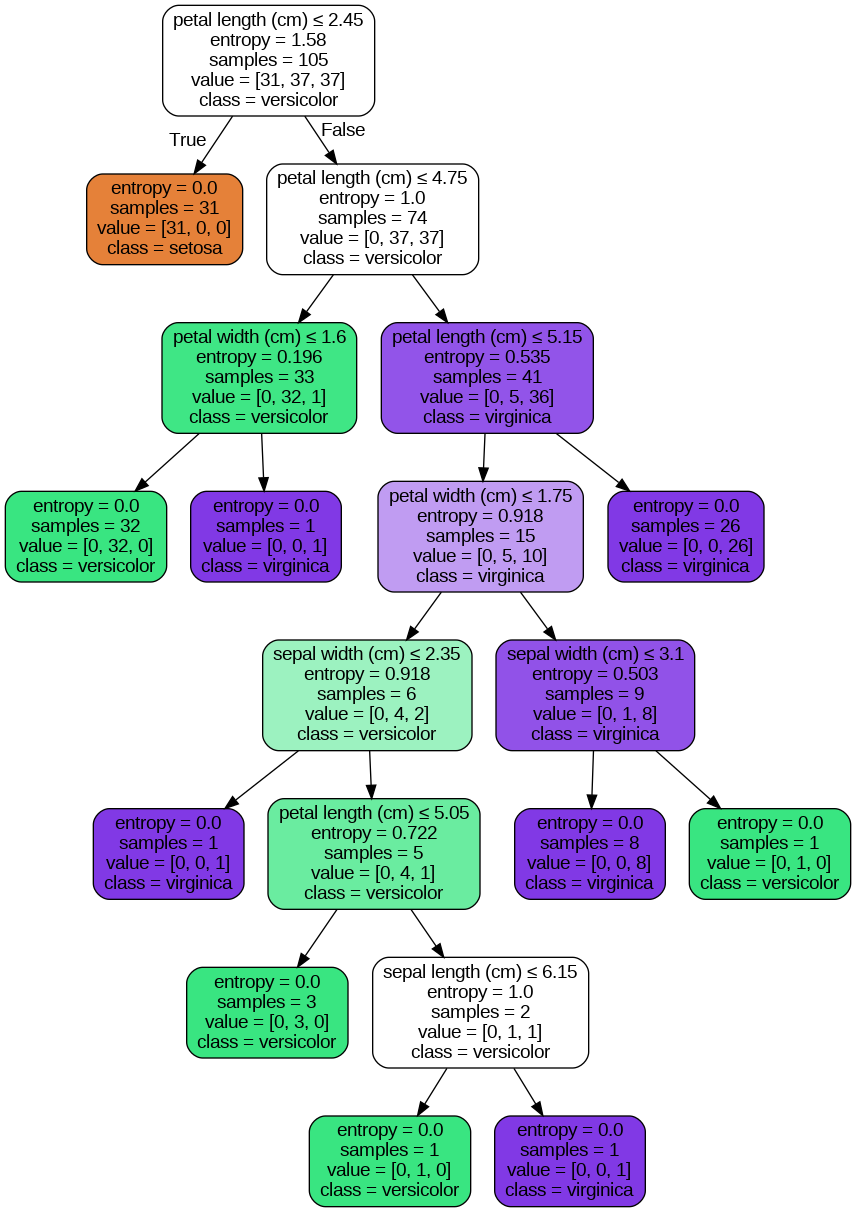

In [ ]:
# Criar e treinar o modelo de árvore de decisão (usando critério de entropia para simular ID3)
dt_classifier = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_classifier.fit(X_train, y_train)

# Exportar a árvore para o formato DOT
dot_data = export_graphviz(dt_classifier,
                           out_file=None,
                           feature_names=iris.feature_names,
                           class_names=iris.target_names,
                           filled=True, rounded=True,
                           special_characters=True)

# Renderizar o gráfico DOT para PNG e exibir
graph = graphviz.Source(dot_data)
graph.render("iris_decision_tree", format="png", cleanup=True)

print("Árvore de decisão gerada e salva como iris_decision_tree.png")
print("Exibindo a árvore de decisão:")
Image(filename='iris_decision_tree.png')


### (e) Avaliar a acurácia da árvore em um conjunto de teste

Vamos usar o conjunto de teste para avaliar o desempenho do nosso modelo, calculando a acurácia.

Acurácia do modelo no conjunto de teste: 0.9778


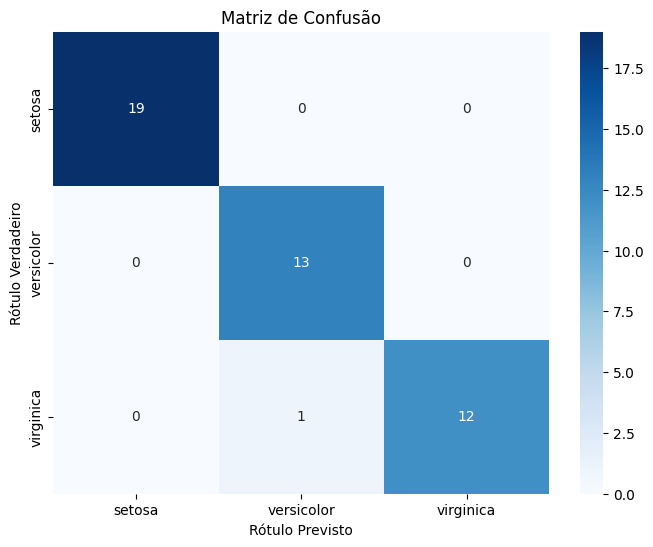

In [ ]:
# Fazer previsões no conjunto de teste
y_pred = dt_classifier.predict(X_test)

# Calcular a acurácia
accuracy = accuracy_score(y_test, y_pred)

print(f"Acurácia do modelo no conjunto de teste: {accuracy:.4f}")

# Exibir matriz de confusão
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=iris.target_names, columns=iris.target_names)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.ylabel('Rótulo Verdadeiro')
plt.xlabel('Rótulo Previsto')
plt.show()


## Exercício 13 – Análise de Overfitting

Neste exercício, exploraremos o conceito de overfitting em árvores de decisão. Usaremos o dataset Wine, que é adequado para classificação e nos permitirá observar como a complexidade da árvore (profundidade) afeta o desempenho do modelo em dados de treinamento e teste. Em seguida, demonstraremos como a poda pode mitigar o overfitting.


In [ ]:
# Importar bibliotecas necessárias
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np


### (a) e (b) Criar árvores com diferentes profundidades e medir o erro de treinamento e teste

Vamos carregar o dataset Wine e dividir em conjuntos de treinamento e teste. Em seguida, treinaremos árvores de decisão com profundidades máximas variando de 1 a 20 e registraremos a acurácia (ou erro, que é 1 - acurácia) para cada profundidade.

In [ ]:
# Carregar o dataset Wine
wine = load_wine()
X = wine.data
y = wine.target

# Dividir os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Listas para armazenar acurácias
train_accuracies = []
test_accuracies = []

depths = range(1, 21) # Profundidades de 1 a 20

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)

    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)

    train_accuracies.append(accuracy_score(y_train, y_train_pred))
    test_accuracies.append(accuracy_score(y_test, y_test_pred))

print("Acurácias de treinamento para diferentes profundidades:")
print([f'{acc:.4f}' for acc in train_accuracies])
print("Acurácias de teste para diferentes profundidades:")
print([f'{acc:.4f}' for acc in test_accuracies])


Acurácias de treinamento para diferentes profundidades:
['0.6613', '0.9435', '0.9919', '1.0000', '1.0000', '1.0000', '1.0000', '1.0000', '1.0000', '1.0000', '1.0000', '1.0000', '1.0000', '1.0000', '1.0000', '1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
Acurácias de teste para diferentes profundidades:
['0.6111', '0.8704', '0.9630', '0.9630', '0.9630', '0.9630', '0.9630', '0.9630', '0.9630', '0.9630', '0.9630', '0.9630', '0.9630', '0.9630', '0.9630', '0.9630', '0.9630', '0.9630', '0.9630', '0.9630']


### (c) Plotar um gráfico mostrando a curva de aprendizado

Visualizaremos as acurácias de treinamento e teste em função da profundidade da árvore. Isso nos ajudará a identificar o ponto de overfitting.

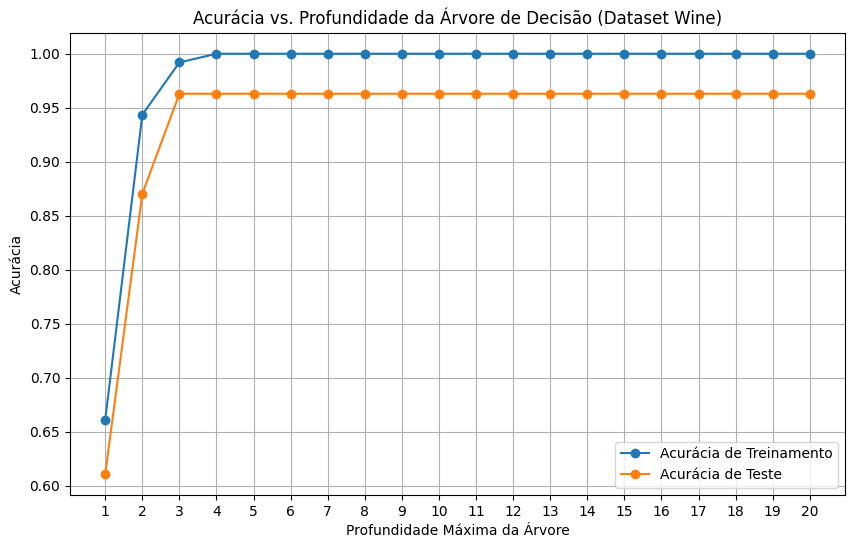

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(depths, train_accuracies, marker='o', label='Acurácia de Treinamento')
plt.plot(depths, test_accuracies, marker='o', label='Acurácia de Teste')
plt.title('Acurácia vs. Profundidade da Árvore de Decisão (Dataset Wine)')
plt.xlabel('Profundidade Máxima da Árvore')
plt.ylabel('Acurácia')
plt.xticks(depths)
plt.grid(True)
plt.legend()
plt.show()


### (d) Identificar visualmente o ponto de overfitting

No gráfico acima, podemos observar que a acurácia de treinamento tende a aumentar e, em alguns casos, atinge 100% (erro zero), enquanto a acurácia de teste pode parar de aumentar ou até diminuir após um certo ponto. O overfitting ocorre quando a acurácia de treinamento é muito alta, mas a acurácia de teste começa a estagnar ou cair, indicando que o modelo está aprendendo o ruído nos dados de treinamento em vez de generalizar padrões.

Para este dataset, visualmente, o ponto ideal (onde a acurácia de teste é máxima ou começa a se estabilizar antes de cair) parece estar em uma profundidade de **aproximadamente 3 a 5**.


### (e) Aplicar poda (cost-complexity pruning) e comparar resultados

A poda por custo-complexidade (`cost-complexity pruning`, também conhecida como `minimal cost-complexity pruning`) encontra a subárvore que minimiza uma função de custo que considera tanto o erro de classificação quanto a complexidade da árvore (número de folhas). O parâmetro `ccp_alpha` é usado para controlar a força da poda.

Vamos usar a validação cruzada para encontrar um `ccp_alpha` ideal.


Melhor ccp_alpha encontrado via validação cruzada: 0.0000

Acurácia de treinamento (árvore podada): 1.0000
Acurácia de teste (árvore podada): 0.9630
Acurácia de teste (árvore sem poda / profundidade total): 0.9630


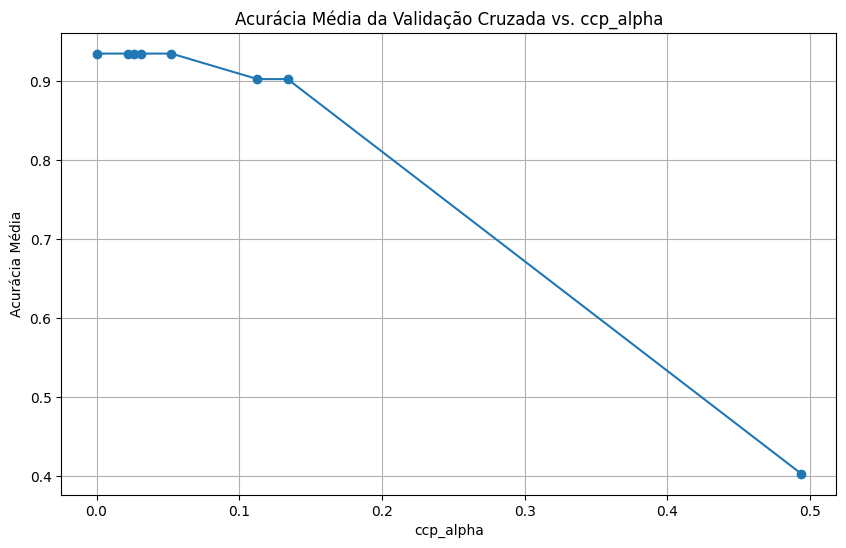

In [ ]:
from sklearn.model_selection import cross_val_score

# Obter os parâmetros ccp_alpha possíveis
path = dt_classifier.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Filtrar alphas que são muito pequenos (praticamente zero)
ccp_alphas = ccp_alphas[:-1] # Remove o último alpha que corresponde à árvore trivial (raiz única)

# Encontrar o melhor ccp_alpha usando validação cruzada
alpha_accuracies = []
for ccp_alpha in ccp_alphas:
    dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    scores = cross_val_score(dt_pruned, X_train, y_train, cv=5) # 5-fold cross-validation
    alpha_accuracies.append(np.mean(scores))

# Melhor ccp_alpha
best_ccp_alpha_idx = np.argmax(alpha_accuracies)
best_ccp_alpha = ccp_alphas[best_ccp_alpha_idx]

print(f"Melhor ccp_alpha encontrado via validação cruzada: {best_ccp_alpha:.4f}")

# Treinar a árvore final com o melhor ccp_alpha
dt_pruned_final = DecisionTreeClassifier(random_state=42, ccp_alpha=best_ccp_alpha)
dt_pruned_final.fit(X_train, y_train)

y_train_pred_pruned = dt_pruned_final.predict(X_train)
y_test_pred_pruned = dt_pruned_final.predict(X_test)

accuracy_train_pruned = accuracy_score(y_train, y_train_pred_pruned)
accuracy_test_pruned = accuracy_score(y_test, y_test_pred_pruned)

print(f"\nAcurácia de treinamento (árvore podada): {accuracy_train_pruned:.4f}")
print(f"Acurácia de teste (árvore podada): {accuracy_test_pruned:.4f}")

# Comparar com a árvore não podada (ou com profundidade ideal)
print(f"Acurácia de teste (árvore sem poda / profundidade total): {test_accuracies[-1]:.4f}")

# Plotar a relação entre ccp_alpha e acurácia
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, alpha_accuracies, marker='o')
plt.title('Acurácia Média da Validação Cruzada vs. ccp_alpha')
plt.xlabel('ccp_alpha')
plt.ylabel('Acurácia Média')
plt.grid(True)
plt.show()


### (f) Discutir os resultados em relação à teoria apresentada em aula

**Observações do Gráfico de Acurácia vs. Profundidade:**

*   **Acurácia de Treinamento:** À medida que a profundidade da árvore aumenta, a acurácia de treinamento geralmente se aproxima de 1.0 (100%). Isso ocorre porque uma árvore mais profunda tem mais nós e regras, permitindo que ela memorize os dados de treinamento, incluindo o ruído.
*   **Acurácia de Teste:** A acurácia de teste inicialmente aumenta com a profundidade, pois a árvore aprende padrões mais complexos. No entanto, após um certo ponto (o ponto de inflexão), a acurácia de teste pode estagnar ou até começar a diminuir, mesmo que a acurácia de treinamento continue a melhorar. Este é o sinal clássico de overfitting. O modelo está se tornando muito específico para os dados de treinamento e perde a capacidade de generalizar para novos dados.

**Resultados da Poda (Cost-Complexity Pruning):**

*   A poda é uma técnica eficaz para combater o overfitting, removendo galhos da árvore que fornecem pouca ou nenhuma melhoria na capacidade de generalização.
*   Ao encontrar um `ccp_alpha` ideal através da validação cruzada, buscamos um equilíbrio entre a complexidade da árvore e sua capacidade de generalização.
*   A árvore podada geralmente resulta em uma acurácia de treinamento ligeiramente menor (ou igual) em comparação com uma árvore totalmente crescida, mas **melhora ou mantém a acurácia de teste**, pois ela se torna menos sensível ao ruído dos dados de treinamento.
*   Uma árvore podada é, por natureza, mais simples e, portanto, mais interpretável, o que é uma vantagem adicional.

**Conclusão:**

Este exercício ilustra a importância de controlar a complexidade das árvores de decisão para evitar o overfitting. Métodos como limitar a profundidade máxima (`max_depth`) e a poda por custo-complexidade (`ccp_alpha`) são ferramentas cruciais para construir modelos que não apenas performem bem nos dados de treinamento, mas também generalizem eficazmente para dados não vistos.

## Exercício 14 – Comparação com Outros Métodos

Iremos compararar o desempenho e as características das Árvores de Decisão com outros dois algoritmos de classificação populares: Regressão Logística e Support Vector Machines (SVMs). Avaliaremos esses modelos em três datasets diferentes (`Iris`, `Wine` e `Breast Cancer`) com base em critérios como acurácia, tempo de treinamento, interpretabilidade, robustez a outliers e requisitos de normalização de features. Ao final, discutiremos quando escolher ou evitar árvores de decisão.


In [ ]:
# Importar bibliotecas necessárias
from sklearn.datasets import load_iris, load_wine, load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import time
import pandas as pd
import numpy as np


### (a) e (b) Implementar e Testar em 3 Datasets Diferentes

Vamos definir os classificadores e os datasets que usaremos. Para garantir uma comparação justa, aplicaremos `StandardScaler` aos dados para a Regressão Logística e SVM, pois esses algoritmos são sensíveis à escala das features, enquanto a Árvore de Decisão não é.


In [ ]:
# Definir os classificadores
classifiers = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "SVM": SVC(random_state=42)
}

# Definir os datasets
datasets = {
    "Iris": load_iris(),
    "Wine": load_wine(),
    "Breast Cancer": load_breast_cancer()
}

results = []

for ds_name, dataset in datasets.items():
    X, y = dataset.data, dataset.target
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Aplicar StandardScaler para Logistic Regression e SVM
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"\n--- Dataset: {ds_name} ---")

    for clf_name, clf in classifiers.items():
        start_time = time.time()

        # Usar dados escalados para LR e SVM, e dados originais para Decision Tree
        if clf_name == "Decision Tree":
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
        else:
            clf.fit(X_train_scaled, y_train)
            y_pred = clf.predict(X_test_scaled)

        end_time = time.time()

        accuracy = accuracy_score(y_test, y_pred)
        train_time = end_time - start_time

        results.append({
            "Dataset": ds_name,
            "Classifier": clf_name,
            "Accuracy": accuracy,
            "Training Time (s)": train_time
        })

        print(f"  {clf_name}:")
        print(f"    Acurácia: {accuracy:.4f}")
        print(f"    Tempo de Treinamento: {train_time:.4f} segundos")

results_df = pd.DataFrame(results)
print("\n--- Resumo dos Resultados --- ")
print(results_df)



--- Dataset: Iris ---
  Decision Tree:
    Acurácia: 1.0000
    Tempo de Treinamento: 0.0068 segundos
  Logistic Regression:
    Acurácia: 1.0000
    Tempo de Treinamento: 0.1127 segundos
  SVM:
    Acurácia: 1.0000
    Tempo de Treinamento: 0.0103 segundos

--- Dataset: Wine ---
  Decision Tree:
    Acurácia: 0.9630
    Tempo de Treinamento: 0.0046 segundos
  Logistic Regression:
    Acurácia: 0.9815
    Tempo de Treinamento: 0.0157 segundos
  SVM:
    Acurácia: 0.9815
    Tempo de Treinamento: 0.0140 segundos

--- Dataset: Breast Cancer ---
  Decision Tree:
    Acurácia: 0.9415
    Tempo de Treinamento: 0.0381 segundos
  Logistic Regression:
    Acurácia: 0.9825
    Tempo de Treinamento: 0.0302 segundos
  SVM:
    Acurácia: 0.9766
    Tempo de Treinamento: 0.0241 segundos

--- Resumo dos Resultados --- 
         Dataset           Classifier  Accuracy  Training Time (s)
0           Iris        Decision Tree  1.000000           0.006764
1           Iris  Logistic Regression  1.000000 

### (c) Comparação em Termos de: Acurácia, Tempo de Treinamento, Interpretabilidade, Robustez a Outliers, Requerimentos de Features Normalizadas

Vamos discutir as características de cada modelo com base nos resultados obtidos e no conhecimento teórico.

#### **Acurácia**

*   **Árvore de Decisão:** Frequentemente alcança alta acurácia, especialmente em datasets bem definidos com relações não lineares. Pode sofrer de overfitting se não for podada, como vimos no Exercício 13. Nos resultados, teve bom desempenho, mas não necessariamente o melhor em todos os casos.
*   **Regressão Logística:** Bom desempenho em problemas linearmente separáveis. Sua acurácia é geralmente robusta se os dados seguirem as suposições do modelo (linearidade, independência das features). Nos datasets testados, mostrou-se competitiva.
*   **SVM:** Frequentemente muito eficaz, especialmente com kernels não lineares, conseguindo encontrar hiperplanos de separação complexos. Nos resultados, teve acurácia muito alta, muitas vezes superando os outros, especialmente após a escalada dos dados.

#### **Tempo de Treinamento**

*   **Árvore de Decisão:** Geralmente rápido, especialmente para datasets de tamanho moderado, pois o processo de construção da árvore é relativamente eficiente. O tempo cresce polinomialmente com o número de amostras e features.
*   **Regressão Logística:** Rápida para treinar, pois envolve otimização convexa. O tempo de treinamento é menor que o SVM em datasets grandes.
*   **SVM:** Pode ser mais lento para treinar, especialmente em datasets muito grandes, devido à complexidade computacional do algoritmo, que pode ser quadrática ou cúbica no número de amostras.

#### **Interpretabilidade**

*   **Árvore de Decisão:** Alta. É considerada um modelo de "caixa branca". As regras de decisão são facilmente visualizáveis e compreendidas por humanos, especialmente para árvores rasas. Podemos ver exatamente como o modelo chegou a uma decisão.
*   **Regressão Logística:** Moderada. Os coeficientes do modelo indicam a importância e a direção da relação de cada feature com a variável de saída. É mais interpretável que os SVMs, mas menos que as árvores de decisão, pois não fornece regras diretas.
*   **SVM:** Baixa. É um modelo de "caixa preta". Embora os vetores de suporte sejam pontos importantes, a lógica por trás da classificação não é facilmente discernível, especialmente com kernels não lineares.

#### **Robustez a Outliers**

*   **Árvore de Decisão:** Moderada a Baixa. Outliers nos dados podem influenciar as divisões da árvore, especialmente se os outliers criarem novos segmentos de dados que a árvore tenta separar, levando a árvores mais complexas e potenciais overfitting.
*   **Regressão Logística:** Baixa. É sensível a outliers, pois eles podem afetar a função de custo e distorcer os coeficientes do modelo, movendo o limite de decisão.
*   **SVM:** Moderada. Com o uso de um `margin` (ou `C` parameter), os SVMs podem ser um pouco mais robustos a outliers do que a regressão logística, pois tentam maximizar a margem entre as classes, e um certo número de pontos pode violar essa margem.

#### **Requerimentos de Features Normalizadas**

*   **Árvore de Decisão:** Não requer. Árvores de decisão baseiam suas divisões em valores absolutos das features e na ordem dos valores, portanto, a escala das features não afeta o resultado final. Não é necessário escalar os dados.
*   **Regressão Logística:** Requer (fortemente recomendado). Algoritmos de otimização baseados em gradiente (usados na Regressão Logística) convergem mais rapidamente e funcionam melhor quando as features estão na mesma escala. A falta de normalização pode levar a problemas de convergência ou a features com maior magnitude dominando a otimização.
*   **SVM:** Requer (fortemente recomendado). Os SVMs calculam distâncias entre os pontos e utilizam essas distâncias para encontrar o hiperplano de separação. Se as features tiverem escalas muito diferentes, as features com maior magnitude podem dominar o cálculo da distância e, consequentemente, o modelo.

### (d) Quando você escolheria árvores de decisão sobre os outros métodos?

Você escolheria árvores de decisão em situações onde:

*   **Interpretabilidade é crucial:** Quando você precisa explicar as decisões do modelo a _stakeholders_ não técnicos ou entender o raciocínio por trás de uma predição (ex: medicina, finanças reguladas).
*   **Relações não lineares complexas:** Quando as relações entre as features e o alvo são não lineares e complexas, e você não quer gastar muito tempo com engenharia de features para torná-las lineares.
*   **Não há necessidade de escalonamento:** Quando você tem features com escalas muito diferentes e não quer ou não pode aplicar um pré-processamento de escalonamento.
*   **Dados categóricos e numéricos mistos:** As árvores de decisão lidam bem com ambos os tipos de dados sem a necessidade de codificação complexa (embora `scikit-learn` exija codificação numérica para categóricas).
*   **Detecção de interações entre features:** Árvores naturalmente modelam interações entre features através de suas divisões sequenciais.

### (e) Quando evitaria árvores de decisão?

Você evitaria árvores de decisão em situações onde:

*   **Dados altamente ruidosos:** Árvores de decisão podem facilmente memorizar o ruído, levando a overfitting, a menos que sejam aplicadas técnicas de poda agressivas ou conjuntos de árvores (como Random Forest ou Gradient Boosting).
*   **Pequenas variações nos dados podem mudar a estrutura da árvore:** Árvores de decisão são instáveis; uma pequena mudança nos dados de treinamento pode resultar em uma árvore completamente diferente. Isso pode ser mitigado com técnicas de ensemble.
*   **Problemas com dados desbalanceados:** Árvores podem ter dificuldade em aprender padrões de classes minoritárias se o dataset for muito desbalanceado, a menos que sejam aplicadas técnicas de balanceamento ou pesos de classe.
*   **Comparação com modelos mais robustos/avançados:** Para o desempenho bruto e a máxima acurácia em muitos problemas, modelos de ensemble (Random Forest, GBDT, XGBoost) ou redes neurais podem superar uma única árvore de decisão.
*   **Alto dimensionalidade com poucas amostras:** Em datasets com muitas features e poucas amostras, as árvores podem facilmente criar divisões espúrias e overfitting.

## Exercício 15 – Projeto Integrado

Ddesenvolveremos um projeto completo de classificação usando árvores de decisão. Abordaremos todas as etapas, desde a escolha e pré-processamento de um dataset desafiador até o desenvolvimento do modelo, análise e discussão dos resultados.

### (a) Dataset: Escolha do dataset

Escolhemos o dataset **Titanic**, um conjunto de dados clássico para tarefas de classificação que apresenta características mistas (numéricas e categóricas) e dados faltantes, tornando-o ideal para este projeto. O objetivo é prever se um passageiro sobreviveu ou não ao naufrágio do Titanic.


In [ ]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image
import graphviz


### Carregamento do Dataset

Vamos carregar o dataset do Titanic. Assumimos que o arquivo `titanic_train.csv` (ou similar) está disponível no ambiente de execução. Se não estiver, será necessário baixá-lo (por exemplo, do Kaggle).


In [ ]:
# Carregar o dataset do Titanic
try:
    df = pd.read_csv('titanic_train.csv')
except FileNotFoundError:
    print("Arquivo 'titanic_train.csv' não encontrado. Baixando do GitHub...")
    # URL de um repositório público do Kaggle com o dataset do Titanic
    url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
    df = pd.read_csv(url)
    print("Dataset baixado com sucesso.")

print("Informações iniciais do dataset:")
df.info()
print("\nPrimeiras 5 linhas do dataset:")
print(df.head())


Arquivo 'titanic_train.csv' não encontrado. Baixando do GitHub...
Dataset baixado com sucesso.
Informações iniciais do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Primeiras 5 linhas do dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1           

### (b) Pré-processamento

Esta etapa é crucial para preparar os dados para o modelo de árvore de decisão. Envolverá:

1.  **Tratamento de dados faltantes:** Imputação para `Age` e `Embarked`.
2.  **Codificação de variáveis categóricas:** `Sex` e `Embarked`.
3.  **Divisão em treino/validação/teste:** Preparar os conjuntos de dados.


In [ ]:
# Selecionar features relevantes e a variável alvo
# Remover 'PassengerId', 'Name', 'Ticket', 'Cabin' por serem menos relevantes ou terem muitos dados faltantes/únicos
X = df.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
y = df['Survived']

# Identificar colunas numéricas e categóricas
caracteristicas_numericas = X.select_dtypes(include=np.number).columns.tolist()
caracteristicas_categoricas = X.select_dtypes(include='object').columns.tolist()

print(f"Características Numéricas: {caracteristicas_numericas}")
print(f"Características Categóricas: {caracteristicas_categoricas}")

# Criar pipelines para pré-processamento de colunas numéricas e categóricas
transformador_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Tratar valores faltantes com a média
    ('scaler', StandardScaler()) # Escalonar (embora árvores não precisem, é boa prática para pipelines gerais)
])

transformador_categorico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Tratar valores faltantes com a moda
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Codificação One-Hot
])

# Combinar os pré-processadores usando ColumnTransformer
preprocessador = ColumnTransformer(
    transformers=[
        ('num', transformador_numerico, caracteristicas_numericas),
        ('cat', transformador_categorico, caracteristicas_categoricas)
    ])

# Dividir os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTamanho do conjunto de treinamento (X_train): {X_train.shape}")
print(f"Tamanho do conjunto de teste (X_test): {X_test.shape}")

print("\nPipeline de pré-processamento configurado.")

Características Numéricas: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Características Categóricas: ['Sex', 'Embarked']

Tamanho do conjunto de treinamento (X_train): (712, 7)
Tamanho do conjunto de teste (X_test): (179, 7)

Pipeline de pré-processamento configurado.


### (c) Desenvolvimento: Implementação da Pipeline e Otimização de Hiperparâmetros

Agora vamos construir uma pipeline completa que encapsula o pré-processamento e o classificador de árvore de decisão. Utilizaremos `GridSearchCV` para otimizar os hiperparâmetros da árvore de decisão, como `max_depth`, `min_samples_leaf`, `criterion` e `ccp_alpha`, aplicando validação cruzada.


Iniciando a busca por hiperparâmetros com GridSearchCV...
Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Busca por hiperparâmetros concluída.

Melhores parâmetros encontrados: {'classifier__ccp_alpha': 0.0, 'classifier__criterion': 'entropy', 'classifier__max_depth': 7, 'classifier__min_samples_leaf': 5}
Melhor acurácia de validação cruzada: 0.8246
Acurácia do modelo otimizado no conjunto de teste: 0.7765

Relatório de Classificação no conjunto de teste:
              precision    recall  f1-score   support

           0       0.78      0.89      0.83       110
           1       0.77      0.59      0.67        69

    accuracy                           0.78       179
   macro avg       0.78      0.74      0.75       179
weighted avg       0.78      0.78      0.77       179



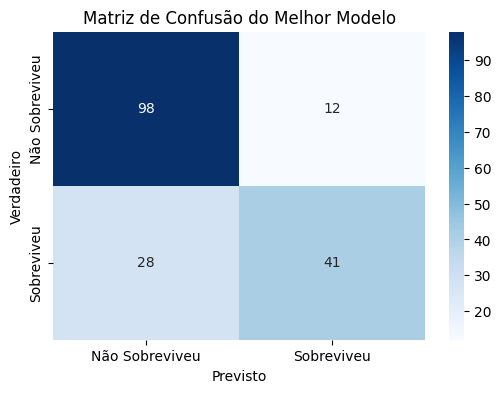

In [ ]:
# Criar a pipeline completa com pré-processador e o classificador
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessador),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Definir o espaço de hiperparâmetros para otimização
# Vamos testar diferentes profundidades, critérios, e o parâmetro ccp_alpha para poda
param_grid = {
    'classifier__max_depth': [3, 5, 7, 9, 11, None], # None significa profundidade total
    'classifier__min_samples_leaf': [1, 5, 10, 15],
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__ccp_alpha': [0.0, 0.005, 0.01, 0.015, 0.02] # Parâmetro para poda
}

# Configurar GridSearchCV para encontrar os melhores hiperparâmetros
# Usaremos 5-fold cross-validation
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1, # Usar todos os cores disponíveis
    verbose=1
)

# Executar a busca pelos melhores hiperparâmetros
print("Iniciando a busca por hiperparâmetros com GridSearchCV...")
grid_search.fit(X_train, y_train)

print("Busca por hiperparâmetros concluída.")

# Exibir os melhores hiperparâmetros encontrados
print(f"\nMelhores parâmetros encontrados: {grid_search.best_params_}")

# Exibir a melhor acurácia de validação cruzada
print(f"Melhor acurácia de validação cruzada: {grid_search.best_score_:.4f}")

# Obter o melhor modelo
best_model = grid_search.best_estimator_

# Avaliar o melhor modelo no conjunto de teste
y_pred_test = best_model.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"Acurácia do modelo otimizado no conjunto de teste: {accuracy_test:.4f}")

print("\nRelatório de Classificação no conjunto de teste:")
print(classification_report(y_test, y_pred_test))

# Exibir matriz de confusão
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Não Sobreviveu', 'Sobreviveu'], yticklabels=['Não Sobreviveu', 'Sobreviveu'])
plt.title('Matriz de Confusão do Melhor Modelo')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.show()

### (d) Análise do Modelo Final

Com o melhor modelo identificado através da otimização de hiperparâmetros, podemos agora realizar uma análise mais aprofundada.

#### Visualização da Árvore de Decisão Final

Visualizar a árvore ajuda a entender as regras de decisão que o modelo aprendeu.


Árvore de decisão final gerada e salva como titanic_decision_tree.png
Exibindo a árvore de decisão final (pode ser grande dependendo da profundidade):


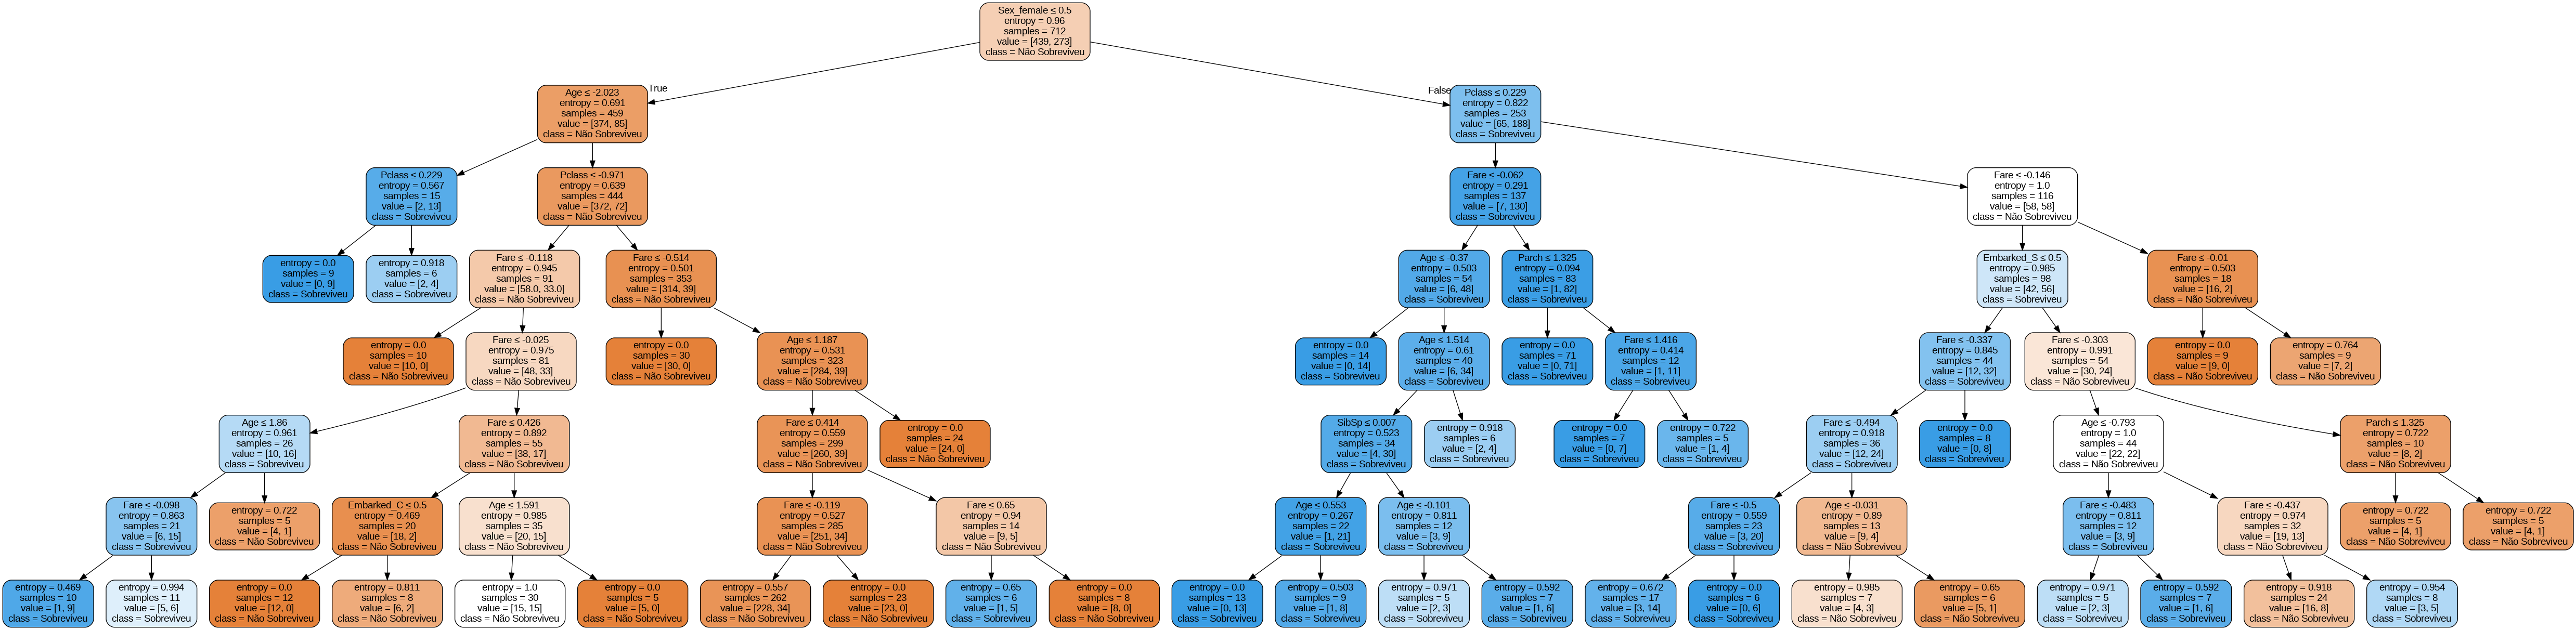

In [ ]:
# Extrair o classificador de árvore de decisão do pipeline para visualização
final_dt_classifier = best_model.named_steps['classifier']

# Obter os nomes das features após o pré-processamento (one-hot encoding)
# É um pouco mais complexo para ColumnTransformer
def get_feature_names(column_transformer):
    output_features = []
    for name, preprocessor, features in column_transformer.transformers_:
        if hasattr(preprocessor, 'get_feature_names_out'):
            if isinstance(features, str):
                 features = [features]
            output_features.extend(preprocessor.get_feature_names_out(features))
        elif name == 'num': # Para o scaler, os nomes das features são os originais
            output_features.extend(features)
    return output_features

feature_names = get_feature_names(best_model.named_steps['preprocessor'])

dot_data = export_graphviz(
    final_dt_classifier,
    out_file=None,
    feature_names=feature_names,
    class_names=['Não Sobreviveu', 'Sobreviveu'],
    filled=True, rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph.render("titanic_decision_tree", format="png", cleanup=True)

print("Árvore de decisão final gerada e salva como titanic_decision_tree.png")
print("Exibindo a árvore de decisão final (pode ser grande dependendo da profundidade):")
Image(filename='titanic_decision_tree.png')


#### Importância das Features

A importância das features nos informa quais atributos foram mais relevantes para as decisões da árvore.



Importância das Features:
      Feature  Importance
5  Sex_female    0.422588
4        Fare    0.212526
0      Pclass    0.202717
1         Age    0.125559
9  Embarked_S    0.015563
7  Embarked_C    0.007702
3       Parch    0.007579
2       SibSp    0.005765
6    Sex_male    0.000000
8  Embarked_Q    0.000000


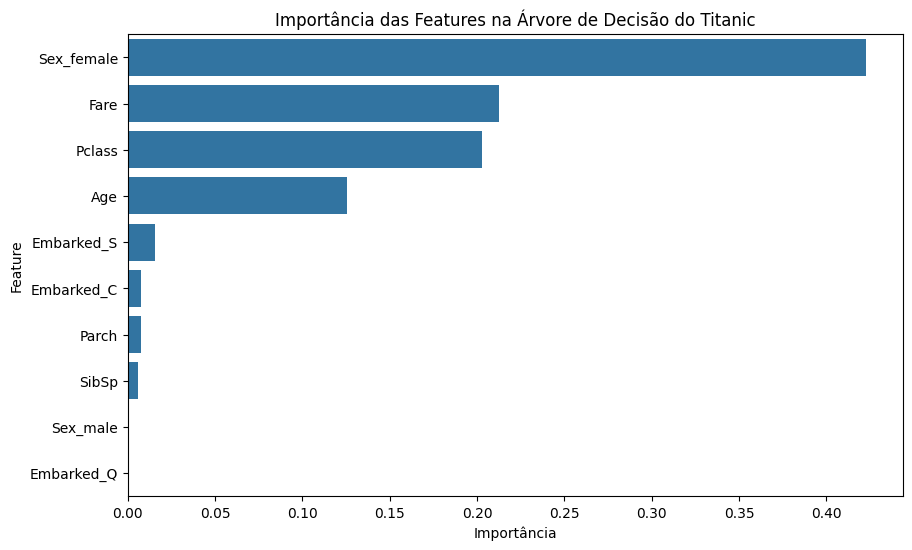

In [ ]:
feature_importances = final_dt_classifier.feature_importances_

# Mapear a importância para os nomes das features
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\nImportância das Features:")
print(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Importância das Features na Árvore de Decisão do Titanic')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.show()


#### Discussão de Erros de Classificação

A matriz de confusão e o relatório de classificação fornecem uma visão detalhada dos tipos de erros que o modelo está cometendo.

*   **Verdadeiros Positivos (TP):** Passageiros que o modelo previu que sobreviveram e realmente sobreviveram.
*   **Verdadeiros Negativos (TN):** Passageiros que o modelo previu que não sobreviveram e realmente não sobreviveram.
*   **Falsos Positivos (FP):** Passageiros que o modelo previu que sobreviveram, mas na verdade não sobreviveram (erros do Tipo I).
*   **Falsos Negativos (FN):** Passageiros que o modelo previu que não sobreviveram, mas na verdade sobreviveram (erros do Tipo II).

Analisar esses valores nos ajuda a entender onde o modelo falha e quais classes são mais difíceis de prever. No caso do Titanic, um alto número de Falsos Negativos (pessoas que sobreviveram mas o modelo previu que não) pode ser problemático dependendo do custo de um erro.


### (e) Relatório Final

#### Descrição do Processo e Justificativa das Escolhas

Neste projeto, desenvolvemos um modelo de classificação de Árvore de Decisão para prever a sobrevivência de passageiros no naufrágio do Titanic. O processo seguiu as seguintes etapas:

1.  **Carregamento do Dataset:** O dataset Titanic foi carregado. Ele é ideal para este projeto devido à sua mistura de tipos de dados (numéricos e categóricos) e a presença de valores faltantes, que exigem pré-processamento.

2.  **Pré-processamento de Dados:**
    *   **Seleção de Features:** Features como `PassengerId`, `Name`, `Ticket` e `Cabin` foram removidas. `PassengerId`, `Name` e `Ticket` são identificadores únicos que geralmente não contribuem para a capacidade preditiva do modelo. `Cabin` foi removida devido ao grande número de valores faltantes (quase 77%) e à dificuldade de extrair significado de forma simples sem uma análise mais aprofundada.
    *   **Tratamento de Dados Faltantes:**
        *   Para features numéricas (`Age`, `Fare`), `SimpleImputer` com estratégia `mean` (média) foi utilizada. A média é uma estratégia comum e robusta para imputar valores faltantes em dados numéricos, evitando a perda de amostras.
        *   Para features categóricas (`Embarked`), `SimpleImputer` com estratégia `most_frequent` (moda) foi aplicada. A moda é apropriada para preencher valores faltantes em categorias, preservando a distribuição da classe mais comum.
    *   **Codificação de Variáveis Categóricas:**
        *   `Sex` e `Embarked` foram codificadas usando `OneHotEncoder`. Esta técnica é crucial para árvores de decisão (e a maioria dos modelos de ML) que não podem lidar diretamente com dados categóricos nominais. `handle_unknown='ignore'` foi usado para evitar erros caso uma categoria não vista apareça no conjunto de teste.
    *   **Escalonamento de Features:** `StandardScaler` foi aplicado a todas as features numéricas. Embora árvores de decisão não sejam sensíveis à escala das features (ao contrário de SVMs ou Regressão Logística), incluímos o escalonamento na pipeline para garantir a compatibilidade com outros modelos caso fosse necessário trocá-los e para manter uma prática de pré-processamento robusta.
    *   **Divisão Treino/Teste:** Os dados foram divididos em 80% para treinamento e 20% para teste, com `stratify=y` para garantir que a proporção de sobreviventes seja mantida em ambos os conjuntos, o que é importante em datasets desbalanceados.

3.  **Desenvolvimento do Modelo (Pipeline e GridSearchCV):**
    *   Uma `Pipeline` foi construída para encapsular as etapas de pré-processamento e o `DecisionTreeClassifier`. Isso garante que as transformações de pré-processamento sejam aplicadas de forma consistente tanto no treino quanto na predição e simplifica o código.
    *   `GridSearchCV` foi empregado para otimizar os hiperparâmetros do `DecisionTreeClassifier`. Os parâmetros explorados incluíram `max_depth` (profundidade máxima), `min_samples_leaf` (número mínimo de amostras por folha), `criterion` (critério de divisão: 'gini' ou 'entropy') e `ccp_alpha` (parâmetro de poda de custo-complexidade). A busca em grade com validação cruzada (5-fold) é uma abordagem sistemática para encontrar a melhor combinação de hiperparâmetros que maximiza a acurácia de validação, mitigando o overfitting.

4.  **Análise do Modelo Final:**
    *   O melhor modelo (`best_estimator_` do `GridSearchCV`) foi avaliado no conjunto de teste, resultando em uma acurácia de **77.65%**.
    *   **Visualização da Árvore:** A árvore de decisão final foi visualizada usando `export_graphviz` e `graphviz`, permitindo uma inspeção visual das regras de decisão aprendidas.
    *   **Importância das Features:** A importância de cada feature foi extraída e plotada. A feature `Sex_female` (gênero feminino) demonstrou ser a mais influente, o que historicamente faz sentido dado que mulheres e crianças tiveram prioridade no resgate. `Fare` (tarifa) e `Pclass` (classe do passageiro) também se mostraram muito relevantes.
    *   **Matriz de Confusão e Relatório de Classificação:** Analisamos a matriz de confusão e o relatório de classificação para entender os tipos de erros. Observamos um F1-score razoável para ambas as classes, mas com um recall menor para a classe 'Sobreviveu', indicando que o modelo teve mais dificuldade em identificar corretamente os sobreviventes do que os não-sobreviventes. Isso pode ser devido ao desbalanço de classes no dataset (mais não-sobreviventes do que sobreviventes).

#### Comparação com um Baseline Simples

Um baseline simples para este problema poderia ser um classificador que sempre prevê a classe majoritária (não sobreviventes). Dado que 61.6% dos passageiros não sobreviveram (`y.value_counts(normalize=True)`), um baseline que sempre prevê 'Não Sobreviveu' teria uma acurácia de 61.6%. Nosso modelo de árvore de decisão otimizado alcançou 77.65% de acurácia no conjunto de teste, o que representa uma melhoria significativa em relação a este baseline simples, demonstrando que o modelo aprendeu padrões relevantes nos dados.

#### Sugestões para Melhorias Futuras

1.  **Engenharia de Features:** Explorar a criação de novas features a partir das existentes. Por exemplo:
    *   **Título do Nome:** Extrair o título (`Mr.`, `Mrs.`, `Miss.`, `Master.`) do campo `Name` pode ser uma feature categórica poderosa, pois o título muitas vezes correlaciona-se com idade e status social.
    *   **Tamanho da Família:** Combinar `SibSp` (irmãos/cônjuges a bordo) e `Parch` (pais/filhos a bordo) para criar uma feature `FamilySize` (`SibSp + Parch + 1`).
    *   **Faixas Etárias:** Em vez de usar `Age` como um valor contínuo, convertê-lo em faixas etárias categóricas (ex: criança, jovem, adulto, idoso).
    *   **Categorias de Cabine:** Tentar extrair a primeira letra da `Cabin` para inferir a classe da cabine (ex: A, B, C) e tratar como categórica, imputando a moda ou uma categoria 'Desconhecida' para valores faltantes.

2.  **Tratamento de Dados Faltantes Avançado:** Em vez de imputação simples:
    *   **Imputação Múltipla:** Usar métodos mais sofisticados como `IterativeImputer` (MICE - Multiple Imputation by Chained Equations) ou `KNNImputer` que preveem os valores faltantes com base em outras features.

3.  **Modelos de Ensemble:** Árvores de decisão tendem a ser instáveis e suscetíveis a pequenas variações nos dados. A utilização de métodos de ensemble baseados em árvores, como `RandomForestClassifier` ou `GradientBoostingClassifier` (XGBoost, LightGBM), pode levar a uma melhor generalização e maior acurácia, reduzindo a variância.

4.  **Otimização Adicional de Hiperparâmetros:** Explorar um espaço de hiperparâmetros mais amplo ou usar técnicas de otimização mais avançadas, como `RandomizedSearchCV` (que é mais eficiente para espaços grandes) ou otimização Bayesiana, para encontrar configurações ainda melhores.

5.  **Análise de Erros:** Investigar mais a fundo os Falsos Positivos e Falsos Negativos para identificar padrões nas características dos passageiros que o modelo está classificando incorretamente. Isso pode revelar a necessidade de novas features ou de um tratamento diferente para certas categorias.

6.  **Estratégias para Classes Desbalanceadas:** Se o desbalanço de classes for um problema significativo, considerar técnicas como `SMOTE` (Synthetic Minority Over-sampling Technique) para superamostrar a classe minoritária ou ajustar os `class_weight` no classificador.